# Laboratorio 3 RNN y LSTM



In [2]:
!pip uninstall huggingface-hub datasets transformers tokenizers -y
!pip install huggingface-hub==0.20.3 datasets==2.15.0 transformers==4.36.0 tokenizers==0.15.0

Found existing installation: huggingface_hub 1.28.0
Uninstalling huggingface_hub-1.28.0:
  Successfully uninstalled huggingface_hub-1.28.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: transformers 5.15.1
Uninstalling transformers-5.15.1:
  Successfully uninstalled transformers-5.15.1
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.5/318.5 kB 6.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer
import torch
from collections import Counter


Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [5]:
print("=== CARGA DE DATOS IMDB ===")

#dataset imdb
imdb = load_dataset("imdb", split=None)
print("Datos cargados")

=== CARGA DE DATOS IMDB ===


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Datos cargados


=== EXPLORACION INICIAL ===
--- OBSERVACIONES Y BALANCE ---

Total observaciones: 50000
 - Entrenamiento: 25000
 - Test: 25000

Distribucion clases (entrenamiento)
  Positivas: 12500 (50.00%)
  Negativas: 12500 (50.00%)

Distribucion clases (test)
  Positivas: 12500 (50.00%)
  Negativas: 12500 (50.00%)

--- LONGITUD RESEÑAS ---
Procesando muestra #5000...
Procesando muestra #10000...
Procesando muestra #15000...
Procesando muestra #20000...

Longitud reseñas (No. palabras):
  Min: 10
  Max: 2470
  Promedio: 233.79
  Mediana: 174.00
  Desviacion estandar: 173.73

Percentiles:
  25%: 127
  50%: 174
  75%: 284
  90%: 458
  95%: 598
  99%: 913


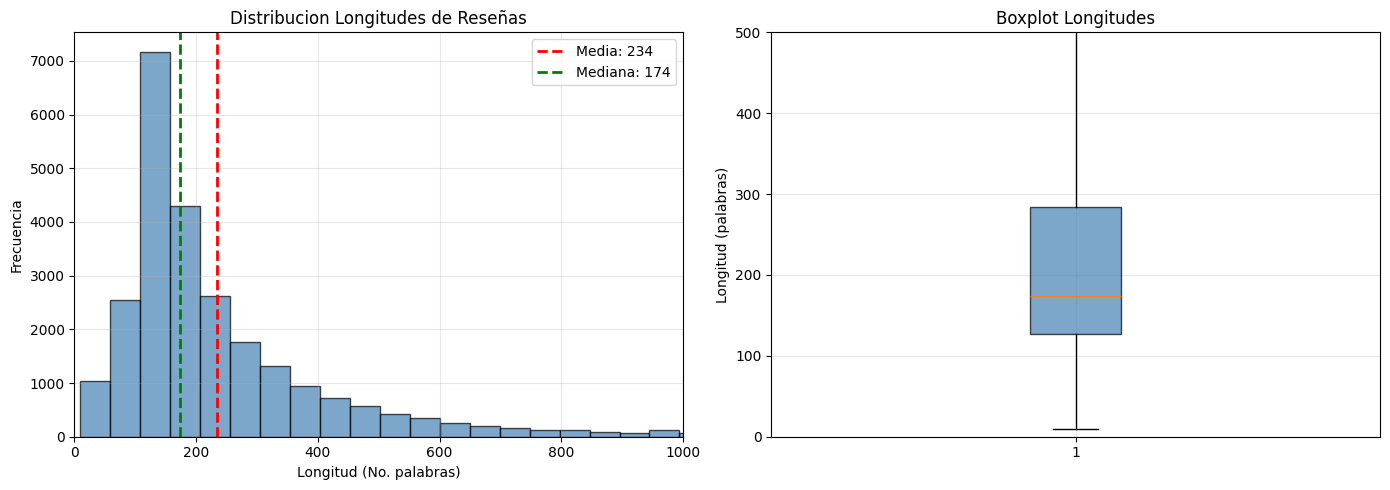

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Texto original: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
Tokens (primeros 20): ['i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when']...
Número de tokens: 361

Tamaño del vocabulario BERT: 30522
Token OOV: [UNK] (ID: 100)
Estrategia: Subword tokenization (WordPiece)

Ejemplo con palabra rara: Texto inusual para ejemplo
Tokens: ['text', '##o', 'in', '##us', '##ual', 'para', 'e', '##je', '##mp', '##lo']


In [6]:
print("=== EXPLORACION INICIAL ===")

print("--- OBSERVACIONES Y BALANCE ---")
train_count = len(imdb['train'])
test_count = len(imdb['test'])
total_count = train_count+test_count
print(f"\nTotal observaciones: {total_count}")
print(f" - Entrenamiento: {train_count}\n - Test: {test_count}")

#balance train
train_labels = imdb['train']['label']
train_positive = sum(train_labels)
train_negative = len(train_labels)-train_positive
print(f"\nDistribucion clases (entrenamiento)")
print(f"  Positivas: {train_positive} ({train_positive/len(train_labels)*100:.2f}%)")
print(f"  Negativas: {train_negative} ({train_negative/len(train_labels)*100:.2f}%)")

#balance test
test_labels = imdb['test']['label']
test_positive = sum(test_labels)
test_negative = len(test_labels)-test_positive
print(f"\nDistribucion clases (test)")
print(f"  Positivas: {test_positive} ({test_positive/len(test_labels)*100:.2f}%)")
print(f"  Negativas: {test_negative} ({test_negative/len(test_labels)*100:.2f}%)")


print("\n--- LONGITUD RESEÑAS ---")
#token. cont. palabras
def get_text_lengths(dataset, max_samples=None):
    lengths = []
    texts = dataset['text']
    if max_samples:
        texts = texts[:max_samples]
    for i, text in enumerate(texts):
        tokens = text.split()
        lengths.append(len(tokens))
        if i % 5000 == 0 and i > 0:
            print(f"Procesando muestra #{i}...")
    return lengths
train_lengths = get_text_lengths(imdb['train'])
train_lengths_np = np.array(train_lengths)

print(f"\nLongitud reseñas (No. palabras):")
print(f"  Min: {np.min(train_lengths_np)}")
print(f"  Max: {np.max(train_lengths_np)}")
print(f"  Promedio: {np.mean(train_lengths_np):.2f}")
print(f"  Mediana: {np.median(train_lengths_np):.2f}")
print(f"  Desviacion estandar: {np.std(train_lengths_np):.2f}")

percentiles = [25, 50, 75, 90, 95, 99]
print(f"\nPercentiles:")
for p in percentiles:
    print(f"  {p}%: {np.percentile(train_lengths_np, p):.0f}")

#graficas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histograma
axes[0].hist(train_lengths_np, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(train_lengths_np), color='red', linestyle='--', linewidth=2,
                label=f'Media: {np.mean(train_lengths_np):.0f}')
axes[0].axvline(np.median(train_lengths_np), color='green', linestyle='--', linewidth=2,
                label=f'Mediana: {np.median(train_lengths_np):.0f}')
axes[0].set_xlabel('Longitud (No. palabras)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion Longitudes de Reseñas')
axes[0].legend()
axes[0].set_xlim([0, 1000])
axes[0].grid(True, alpha=0.3)

#boxplot
axes[1].boxplot(train_lengths_np, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_ylabel('Longitud (palabras)')
axes[1].set_title('Boxplot Longitudes')
axes[1].set_ylim([0, 500])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#tokenizacion
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

#ejs token.
sample_text = imdb['train']['text'][0]
tokens = tokenizer.tokenize(sample_text)
print(f"Texto original: {sample_text[:100]}...")
print(f"Tokens (primeros 20): {tokens[:20]}...")
print(f"Número de tokens: {len(tokens)}")

#tamaño vocab
vocab_size = tokenizer.vocab_size
print(f"\nTamaño del vocabulario BERT: {vocab_size}")

#OOV (Out-of-Vocabulary)
print(f"Token OOV: {tokenizer.unk_token} (ID: {tokenizer.unk_token_id})")
print(f"Estrategia: Subword tokenization (WordPiece)")

#ejemplo OOV
unusual_text = "Texto inusual para ejemplo"
tokens_unusual = tokenizer.tokenize(unusual_text)
print(f"\nEjemplo con palabra rara: {unusual_text}")
print(f"Tokens: {tokens_unusual}")

##### ¿Por qué es necesario aplicar padding y/o truncamiento a las secuencias antes de agruparlas en batches? ¿Qué longitud máxima de secuencia eligieron y por qué?


Es necesario aplicarlos porque los batches requieren tensores que sean de tamaños uniformes, las rnn reciben entradas de dimesniones fijas y es óptimo para los modelos. Usar el percentil del 95% indica que la longitud maxima de 598 tokens corresponde al 95% de las reviews. Y tambien se evita procesar reviews con una cantidad enorme de tokens y así se agiliza el proceso.


La estrategia de truncamiento es al inicio desde la izquierda, conservando el incio de la reseña (que mayorente da el contexto)

In [7]:
#long max (per)
max_len = int(np.percentile(train_lengths_np, 95))
print(f"Longitud maxima: {max_len} tokens (percentil 95%)")

truncated_count = sum(1 for length in train_lengths_np if length > max_len)
print(f"\nReseñas que seran truncadas: {truncated_count} ({truncated_count/len(train_lengths_np)*100:.2f}%)")

#ejemplos
np.random.seed(42)
indices = np.random.choice(min(1000, len(imdb['train'])), 5, replace=False)

for i, idx in enumerate(indices):
    text = imdb['train']['text'][idx]
    label = imdb['train']['label'][idx]
    tokens = tokenizer.tokenize(text)

    print(f"\n--- Ejemplo {i+1} ---")
    print(f"ID: {idx}")
    print(f"Sentimiento: {'POSITIVO' if label == 1 else 'NEGATIVO'}")
    print(f"Texto: {text[:200]}...")
    print(f"No. tokens originales: {len(text.split())}")
    print(f"No. tokens BERT: {len(tokens)}")
    print(f"Tokens (primeros 15): {tokens[:15]}")

Token indices sequence length is longer than the specified maximum sequence length for this model (666 > 512). Running this sequence through the model will result in indexing errors


Longitud maxima: 598 tokens (percentil 95%)

Reseñas que seran truncadas: 1249 (5.00%)

--- Ejemplo 1 ---
ID: 521
Sentimiento: NEGATIVO
Texto: This movie could be used in film classes in a "How Not to Script a B-Movie" course. There are inherent constrictions in a B-movie: Budgets are tight, Time is precious (Scarecrow was apparently shot in...
No. tokens originales: 505
No. tokens BERT: 666
Tokens (primeros 15): ['this', 'movie', 'could', 'be', 'used', 'in', 'film', 'classes', 'in', 'a', '"', 'how', 'not', 'to', 'script']

--- Ejemplo 2 ---
ID: 737
Sentimiento: NEGATIVO
Texto: Prom Night is about a girl named Donna (Brittany Snow) who is being chased by a psycho killer trying to kill her at her prom night. And by doing so killing her family, friends, and her enemies. <br />...
No. tokens originales: 305
No. tokens BERT: 407
Tokens (primeros 15): ['prom', 'night', 'is', 'about', 'a', 'girl', 'named', 'donna', '(', 'brittany', 'snow', ')', 'who', 'is', 'being']

--- Ejemplo 3 ---
ID: 74

Estrategia: BERT con subword tokenization (El manejo de palabras fuera del vocabulario (OOV) consiste en descompener las palabras en subpalabras. Se logra un balance entre tokens en su cobetura de palabras)

=== DIVISION DE DATOS ===
Dataset Entrenamiento: 20000 observaciones
Dataset Validación: 5000 observaciones
Dataset Test: 25000 observaciones

Distribucion validacion:
  Positivas: 2506 (50.12%)
  Negativas: 2494 (49.88%)
--- TOKENIZACION PIPELINE ---
Tokenizando datasets...


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


=== RESUMEN FINAL ===
Tamaño vocabulario: 30522
Longitud max: 598
Formato datasets tokenizados:
 - Entrenamiento: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 20000
})
 - Validacion: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})
 - Test: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25000
})

Estadisticas descriptivas:
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: longitud, dtype: float64


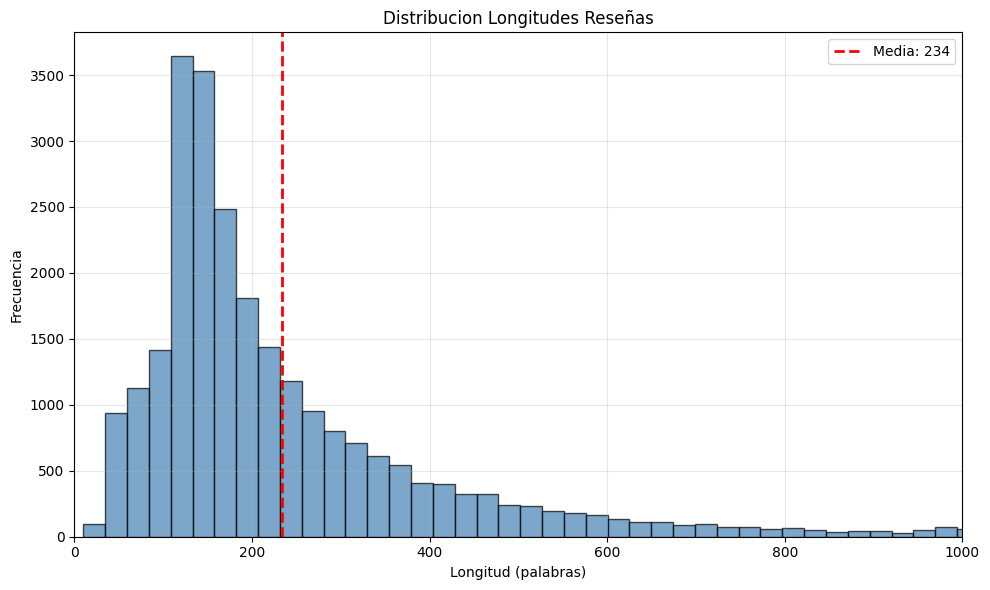

In [8]:
#DIVISION
print("=== DIVISION DE DATOS ===")

test_dataset = imdb['test']
#division 80/20
train_val_split = imdb['train'].train_test_split(test_size=0.2, seed=42)
train_dataset = train_val_split['train']
val_dataset = train_val_split['test']

print(f"Dataset Entrenamiento: {len(train_dataset)} observaciones")
print(f"Dataset Validación: {len(val_dataset)} observaciones")
print(f"Dataset Test: {len(test_dataset)} observaciones")

val_labels = val_dataset['label']
val_positive = sum(val_labels)
val_negative = len(val_labels) - val_positive
print(f"\nDistribucion validacion:")
print(f"  Positivas: {val_positive} ({val_positive/len(val_labels)*100:.2f}%)")
print(f"  Negativas: {val_negative} ({val_negative/len(val_labels)*100:.2f}%)")

print("--- TOKENIZACION PIPELINE ---")

def tokenize_function(examples, max_length=max_len):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors=None
    )

#datasets tok.
print("Tokenizando datasets...")
train_dataset_tokenized = train_dataset.map(tokenize_function, batched=True)
val_dataset_tokenized = val_dataset.map(tokenize_function, batched=True)
test_dataset_tokenized = test_dataset.map(tokenize_function, batched=True)

train_dataset_tokenized = train_dataset_tokenized.remove_columns(['text'])
val_dataset_tokenized = val_dataset_tokenized.remove_columns(['text'])
test_dataset_tokenized = test_dataset_tokenized.remove_columns(['text'])

print("\n=== RESUMEN FINAL ===")
print(f"Tamaño vocabulario: {vocab_size}")
print(f"Longitud max: {max_len}")
print(f"Formato datasets tokenizados:")
print(f" - Entrenamiento: {train_dataset_tokenized}")
print(f" - Validacion: {val_dataset_tokenized}")
print(f" - Test: {test_dataset_tokenized}")

lengths_df = pd.DataFrame({
    'longitud': train_lengths_np
})
print("\nEstadisticas descriptivas:")
print(lengths_df['longitud'].describe())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(train_lengths_np, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.mean(train_lengths_np), color='red', linestyle='--', linewidth=2,
           label=f'Media: {np.mean(train_lengths_np):.0f}')
ax.set_xlabel('Longitud (palabras)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion Longitudes Reseñas')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1000])
plt.legend()
plt.tight_layout()
plt.show()

### Investigación: capas de PyTorch para RNN y LSTM
-	nn.Embedding: capa que funciona como tabla de búsqueda, transforma números enteros (como índices) en vectores de números reales, capturando el significado y lreaciones de los datos. Sus parámetros son num_embeddings (tamaño total diccionario) y embedding_dim (tamaño de vectores resultantes)
-	nn.RNN: Crea una red neuronal recurrente base, cumpliendo con las funciones de una red de este tipo.
-	nn.LSTM: Crea capas de redes neuronales tipo lstm haciendo uso de compuertas para decidir que hacer con la informacion.
-	nn.utils.rnn.pad_sequence: rellena (con 0 u otros valores) una lista de tensores que tengan distintas longitudes para que todas tengan el mismo tamaño
-	pack_padded_sequence: toma los tensores que ya fueron rellenados y compacta al eliminar los valores de relleno, haciendo que el rnn ignore esos valores con el fin de ser mas eficiente y mejorar gradientes.
-	pad_packed_sequence: Conversion de secuencia que fue compactada en un tensor rellenado, permitiendo trabajar con capas normales
-	torch.nn.utils.clip_grad_norm_ (gradient clipping): recorta la norma de los exploding gradients, se usa durante el entrenamiento y estabiliza la actualización de los pesos
-	nn.Dropout aplicado a capas recurrentes: Debe ser con cuidado ya que se podría causar la corrupción de la memoria a largo plazo de la secuencia.
<br>CONCEPTOS:<br>
- Diferencia hidden state y cell state en LSTM: hidden state es la memoria de corto plazo y output en el paso en ese momento mientras que cell state es la memoria a largo plazo, esta guarda la información principal de la secuencia con cambios mínimos.
- Problema de vanishing / exploding gradient: el problema de vanishing y exploding consiste en que los valores se transforman en valores muy bajos, llegando a casi 0 y causando que la red no aprenda o extremadamente altos y causando un colapso, correspondientemente.
-	Compuertas de LSTM y litigacion de vanishing vs RNN: Se evita el vanishing creando un “carrusel” de error que sea constante y permita que el gradiente fluya aditivamente a lo largo del proceso en lugar de multiplicar. Hay una puerta para olvidar parte de la información que se considere vieja, otra de entrada que determina cual es la información nueva que se va a usar y por ultimo la de salida en la que se se decide que parte del proceso es el output o respuesta final.



### Construcción y entrenamiento de las arquitecturas

In [9]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm import tqdm

In [10]:
#config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

#carga datos
train_ds = load_dataset("imdb", split="train", cache_dir="./imdb_cache")
test_ds = load_dataset("imdb", split="test", cache_dir="./imdb_cache")

train_val_split = train_ds.train_test_split(test_size=0.2, seed=42)
train_dataset_full = train_val_split['train']
val_dataset_full = train_val_split['test']

#mucho tiempo, reduccin
SUBSET_SIZE = 3000
VAL_SIZE = 600
TEST_SIZE = 1000

print("Reducción para optimizacion")

train_dataset = train_dataset_full.select(range(min(SUBSET_SIZE, len(train_dataset_full))))
val_dataset = val_dataset_full.select(range(min(VAL_SIZE, len(val_dataset_full))))
test_dataset = test_ds.select(range(min(TEST_SIZE, len(test_ds))))
print(f"Training: {len(train_dataset)}")
print(f"Validacion: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

#tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 350 #reducido de 598
VOCAB_SIZE = tokenizer.vocab_size
print(f"Vocabulario: {VOCAB_SIZE}")
print(f"Longitud max: {MAX_LEN}")

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors=None
    )

print("\n ...Tokenizacion de datasets...")
train_tokenized = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
val_tokenized = val_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
test_tokenized = test_dataset.map(tokenize_function, batched=True, remove_columns=['text'])

def prepare_dataloader(dataset, batch_size=128, shuffle=True):
    input_ids = torch.tensor(dataset['input_ids'], dtype=torch.long)
    attention_mask = torch.tensor(dataset['attention_mask'], dtype=torch.long)
    labels = torch.tensor(dataset['label'], dtype=torch.long)

    tensor_dataset = TensorDataset(input_ids, attention_mask, labels)
    return DataLoader(tensor_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)

BATCH_SIZE = 128  #+grande = +vel
train_loader = prepare_dataloader(train_tokenized, BATCH_SIZE, shuffle=True)
val_loader = prepare_dataloader(val_tokenized, BATCH_SIZE, shuffle=False)
test_loader = prepare_dataloader(test_tokenized, BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Dispositivo: cpu


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Reducción para optimizacion
Training: 3000
Validacion: 600
Test: 1000
Vocabulario: 30522
Longitud max: 350

 ...Tokenizacion de datasets...


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train batches: 24
Val batches: 5
Test batches: 8


In [11]:
#Def modelos
print("===DEFINICION MODELOS ===")
class MLPBaseline(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims=[256, 128], dropout=0.3):
        super(MLPBaseline, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)

        layers = []
        prev_dim = embedding_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 2))

        self.mlp = nn.Sequential(*layers)

    def forward(self, input_ids, attention_mask):
        embeds = self.embedding(input_ids)#[batch, seq_len, emb_dim]

        #prom emb
        mask = attention_mask.unsqueeze(-1).float()#[batch, seq_len, 1]
        sum_embeds = (embeds * mask).sum(dim=1)#[batch, emb_dim]
        seq_lengths = mask.sum(dim=1)#[batch, 1]
        avg_embeds = sum_embeds / seq_lengths.clamp(min=1)#[batch, emb_dim]

        return self.mlp(avg_embeds)

class SimpleRNN(nn.Module): #many-to-one
    def __init__(self, vocab_size, embedding_dim, hidden_size=128, num_layers=2, dropout=0.3):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            nonlinearity='tanh'
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        embeds = self.embedding(input_ids)

        packed_input = nn.utils.rnn.pack_padded_sequence(
            embeds,
            attention_mask.sum(dim=1).cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, hidden = self.rnn(packed_input)

        last_hidden = hidden[-1]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)

class LSTMModel(nn.Module): #many-to-one
    def __init__(self, vocab_size, embedding_dim, hidden_size=128, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        embeds = self.embedding(input_ids)

        #sec. emp
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embeds,
            attention_mask.sum(dim=1).cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (hidden, cell) = self.lstm(packed_input)

        last_hidden = hidden[-1]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)
print("Modelos definidos")


print("=== ENTRENAMIENTO ===")
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    }
    return metrics

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    }
    return metrics, all_preds, all_labels

def train_model(model, train_loader, val_loader, epochs, lr, device):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_history = []
    val_history = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        #etrenamiento
        train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
        train_history.append(train_metrics)

        #validacion
        val_metrics, _, _ = evaluate(model, val_loader, criterion, device)
        val_history.append(val_metrics)

        print(f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}")
        print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}")

    return train_history, val_history
print("Modelos entrenados")

===DEFINICION MODELOS ===
Modelos definidos
=== ENTRENAMIENTO ===
Modelos entrenados


...Creando dataloaders...
Train batches: 24

Val batches: 5

INICIANDO PRUEBAS (9 EXPERIMENTOS EN TOTAL)

PRUEBAS MLP

--- Prueba MLP 1 ---

Modelo: MLPBaseline
Configuracion: {'vocab_size': 30522, 'embedding_dim': 32, 'hidden_dims': [128, 64], 'dropout': 0.2, 'lr': 0.001}
Parametros entrenables: 989,314

Epoch 1/4


Train - Loss: 0.6932, Acc: 0.5037
Val   - Loss: 0.6918, Acc: 0.5567

Epoch 2/4


Train - Loss: 0.6903, Acc: 0.5513
Val   - Loss: 0.6881, Acc: 0.5783

Epoch 3/4


Train - Loss: 0.6783, Acc: 0.6043
Val   - Loss: 0.6729, Acc: 0.6100

Epoch 4/4


Train - Loss: 0.6447, Acc: 0.6407
Val   - Loss: 0.6409, Acc: 0.6350

--- Prueba MLP 2 ---

Modelo: MLPBaseline
Configuracion: {'vocab_size': 30522, 'embedding_dim': 50, 'hidden_dims': [256, 128], 'dropout': 0.3, 'lr': 0.001}
Parametros entrenables: 1,572,310

Epoch 1/4


...

Train - Loss: 0.6160, Acc: 0.6630
Val   - Loss: 0.6841, Acc: 0.5733

--- Prueba LSTM 3 ---

Modelo: LSTMModel
Configuracion: {'vocab_size': 30522, 'embedding_dim': 50, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.0005}
Parametros entrenables: 2,368,342

Epoch 1/4


Train - Loss: 0.6926, Acc: 0.5217
Val   - Loss: 0.6936, Acc: 0.4967

Epoch 2/4


Train - Loss: 0.6876, Acc: 0.5393
Val   - Loss: 0.6932, Acc: 0.5333

Epoch 3/4


Train - Loss: 0.6762, Acc: 0.5733
Val   - Loss: 0.6775, Acc: 0.5883

Epoch 4/4


Train - Loss: 0.6463, Acc: 0.6263
Val   - Loss: 0.6633, Acc: 0.6100

GENERANDO VISUALIZACIONES


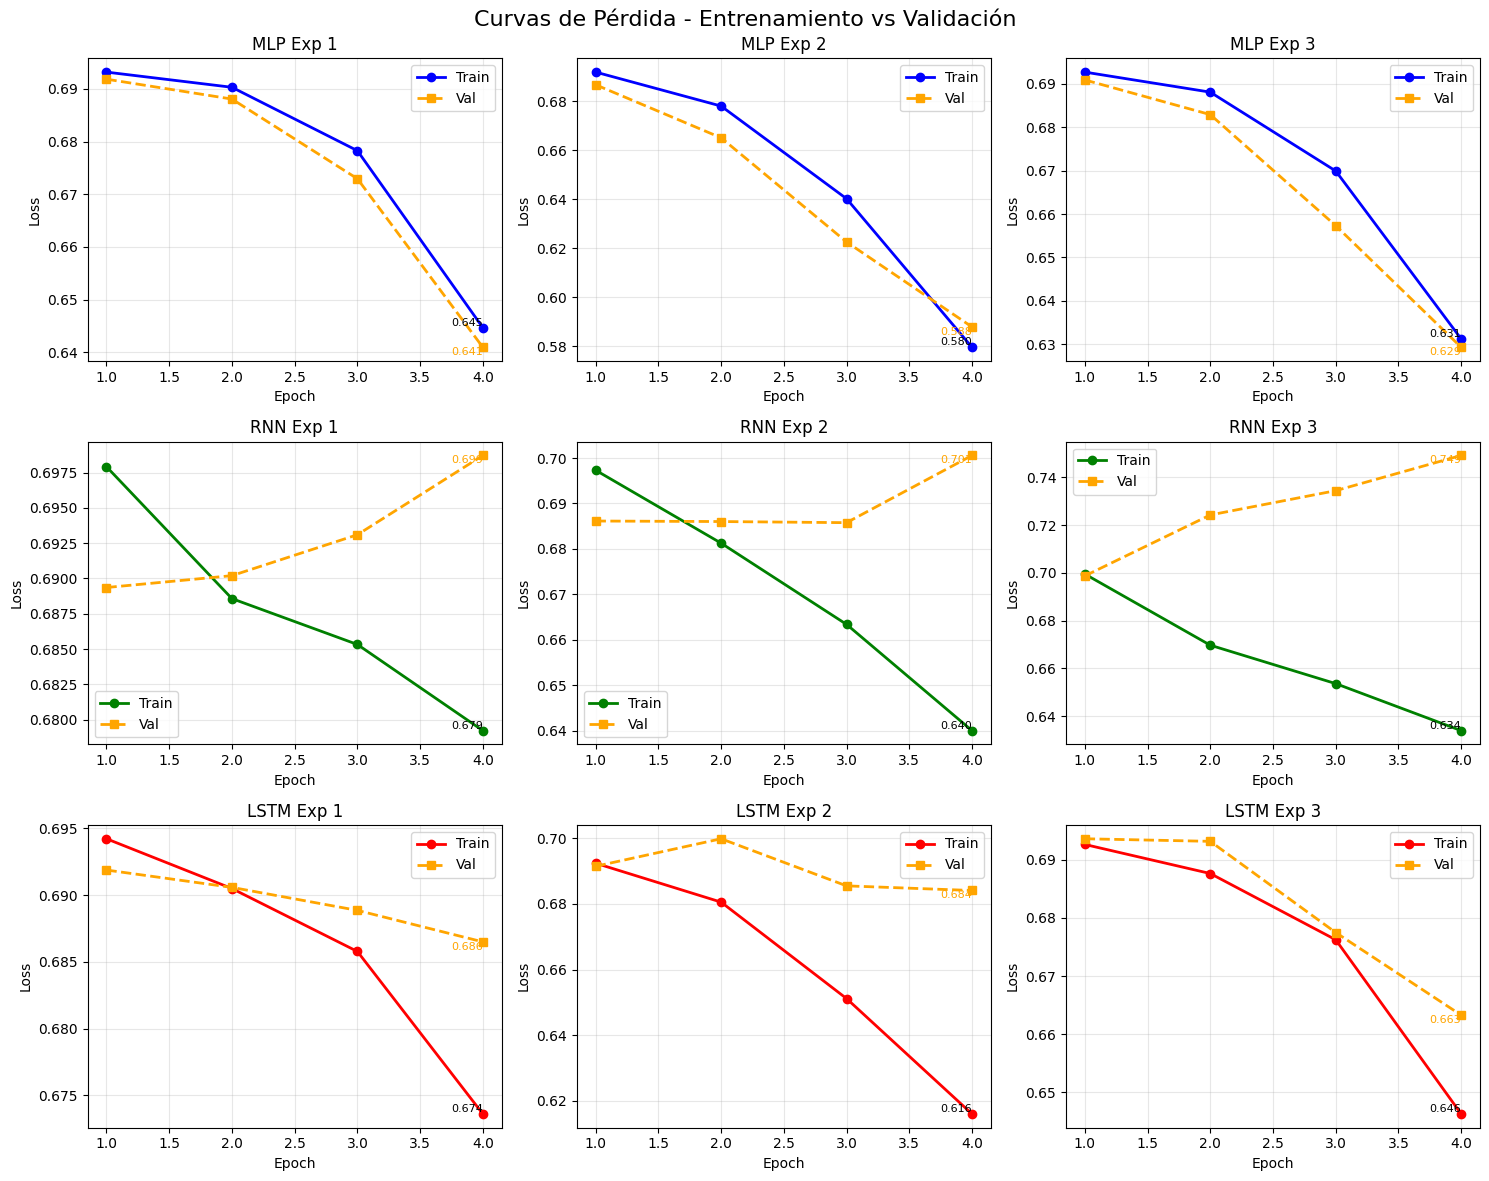

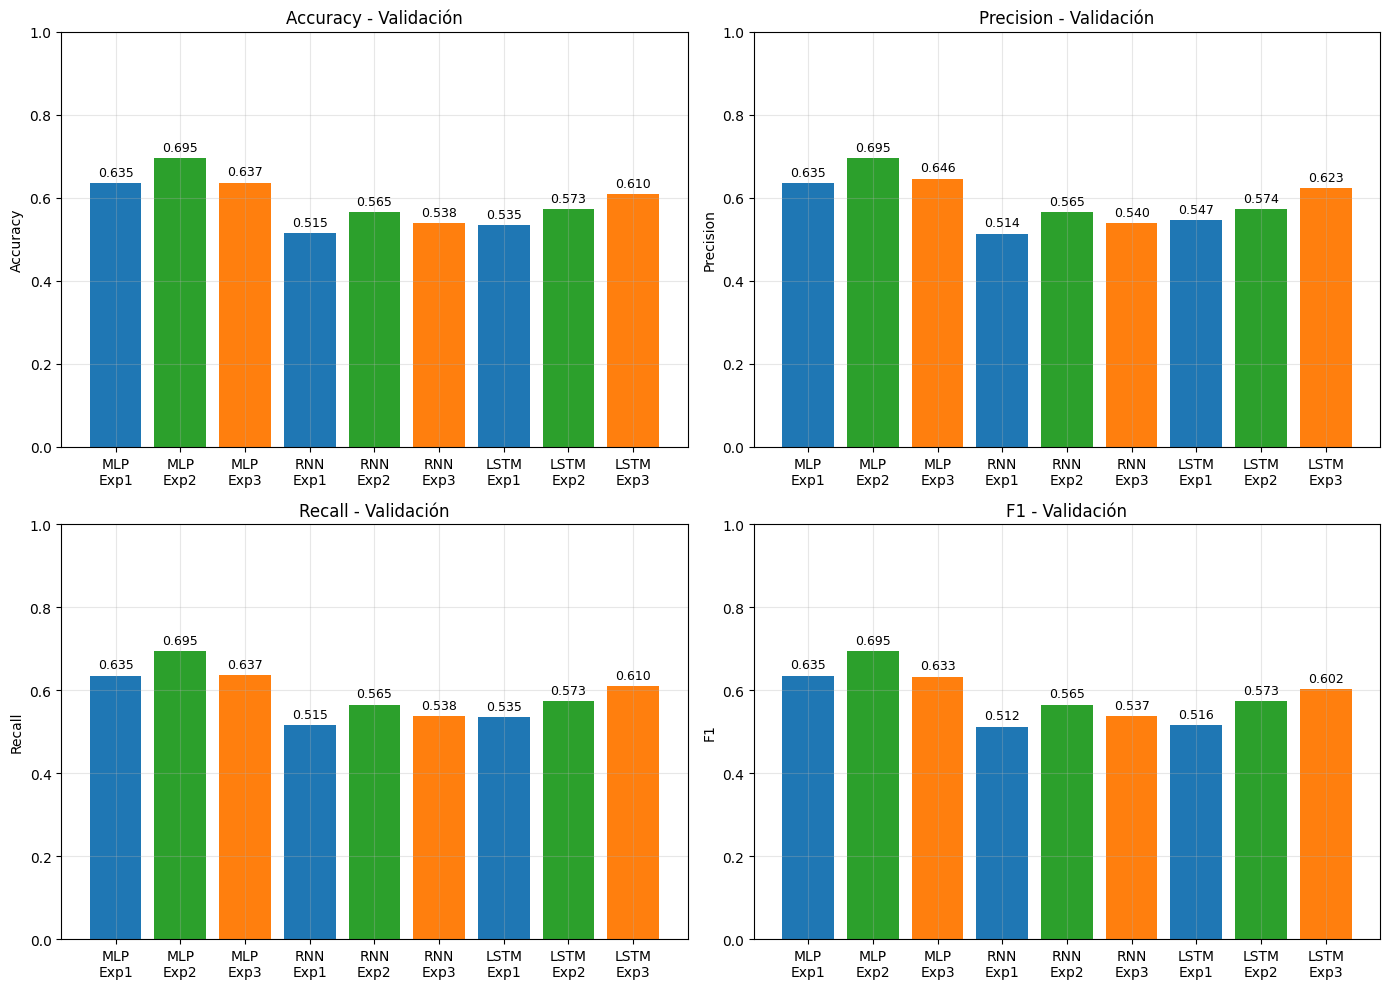

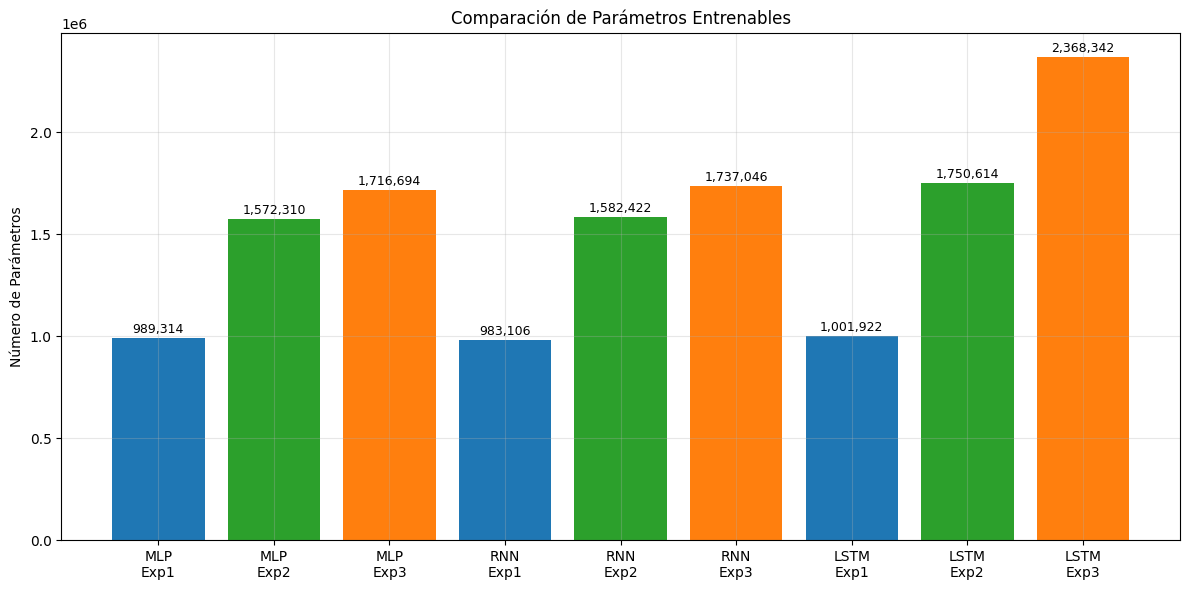

In [12]:
def model_tests(model_class, config, train_loader, val_loader, epochs, device):
    print(f"\n{'='*50}")
    print(f"Modelo: {model_class.__name__}")
    print(f"Configuracion: {config}")
    print(f"{'='*50}")

    lr = config.pop('lr', 0.001)
    model = model_class(**config)
    params = count_parameters(model)
    print(f"Parametros entrenables: {params:,}")

    train_history, val_history = train_model(
        model, train_loader, val_loader, epochs,
        lr=lr, device=device
    )

    config['lr'] = lr

    return {
        'model': model,
        'params': params,
        'train_history': train_history,
        'val_history': val_history,
        'config': config
    }

print("...Creando dataloaders...")
BATCH_SIZE = 128
train_loader = prepare_dataloader(train_tokenized, BATCH_SIZE, shuffle=True)
val_loader = prepare_dataloader(val_tokenized, BATCH_SIZE, shuffle=False)
test_loader = prepare_dataloader(test_tokenized, BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}\n")
print(f"Val batches: {len(val_loader)}")

all_model_tests = []

# Configuraciones MLP - 3 experimentos (valores reducidos para velocidad)
mlp_configs = [
    # Experimento 1: Pequeño y rápido
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 32, 'hidden_dims': [128, 64], 'dropout': 0.2, 'lr': 0.001},
    # Experimento 2: Mediano
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 50, 'hidden_dims': [256, 128], 'dropout': 0.3, 'lr': 0.001},
    # Experimento 3: Más grande
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 50, 'hidden_dims': [512, 256, 128], 'dropout': 0.4, 'lr': 0.0005},
]

# Configuraciones RNN - 3 experimentos
rnn_configs = [
    # Experimento 1: Pequeño y rápido
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001},
    # Experimento 2: Mediano
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 50, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001},
    # Experimento 3: Más grande
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 50, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.0005},
]

# Configuraciones LSTM - 3 experimentos (mismas que RNN para comparación justa)
lstm_configs = [
    # Experimento 1: Pequeño y rápido
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001},
    # Experimento 2: Mediano
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 50, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001},
    # Experimento 3: Más grande
    {'vocab_size': VOCAB_SIZE, 'embedding_dim': 50, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.0005},
]

# ========== EJECUCIÓN DE EXPERIMENTOS ==========
print("\n" + "="*60)
print("INICIANDO PRUEBAS (9 EXPERIMENTOS EN TOTAL)")
print("="*60)

# 🔽 EPOCHS REDUCIDOS DE 5 A 4 PARA VELOCIDAD
EPOCHS = 4

# PRUEBAS MLP
print("\n" + "="*40)
print("PRUEBAS MLP")
print("="*40)
for i, config in enumerate(mlp_configs):
    print(f"\n--- Prueba MLP {i+1} ---")
    result = model_tests(MLPBaseline, config, train_loader, val_loader, epochs=EPOCHS, device=device)
    all_model_tests.append(('MLP', i+1, result))

# PRUEBAS RNN
print("\n" + "="*40)
print("PRUEBAS RNN")
print("="*40)
for i, config in enumerate(rnn_configs):
    print(f"\n--- Prueba RNN {i+1} ---")
    result = model_tests(SimpleRNN, config, train_loader, val_loader, epochs=EPOCHS, device=device)
    all_model_tests.append(('RNN', i+1, result))

# PRUEBAS LSTM
print("\n" + "="*40)
print("PRUEBAS LSTM")
print("="*40)
for i, config in enumerate(lstm_configs):
    print(f"\n--- Prueba LSTM {i+1} ---")
    result = model_tests(LSTMModel, config, train_loader, val_loader, epochs=EPOCHS, device=device)
    all_model_tests.append(('LSTM', i+1, result))

# ========== VISUALIZACIONES ==========
print("\n" + "="*60)
print("GENERANDO VISUALIZACIONES")
print("="*60)

def plot_training_curves(all_model_tests):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle('Curvas de Pérdida - Entrenamiento vs Validación', fontsize=16)

    model_types = ['MLP', 'RNN', 'LSTM']
    colors = ['blue', 'green', 'red']

    for i, model_type in enumerate(model_types):
        for j in range(3):
            ax = axes[i, j]
            exp = next((e for e in all_model_tests if e[0] == model_type and e[1] == j+1), None)
            if exp:
                _, _, result = exp
                train_loss = [epoch['loss'] for epoch in result['train_history']]
                val_loss = [epoch['loss'] for epoch in result['val_history']]

                epochs_range = range(1, len(train_loss) + 1)
                ax.plot(epochs_range, train_loss, 'o-', label='Train', color=colors[i], linewidth=2)
                ax.plot(epochs_range, val_loss, 's--', label='Val', color='orange', linewidth=2)
                ax.set_title(f'{model_type} Exp {j+1}')
                ax.set_xlabel('Epoch')
                ax.set_ylabel('Loss')
                ax.legend()
                ax.grid(True, alpha=0.3)

                # Añadir valores de pérdida final
                ax.text(epochs_range[-1], train_loss[-1], f'{train_loss[-1]:.3f}',
                       fontsize=8, va='bottom', ha='right')
                ax.text(epochs_range[-1], val_loss[-1], f'{val_loss[-1]:.3f}',
                       fontsize=8, va='top', ha='right', color='orange')

    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(all_experiments):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metrics = ['accuracy', 'precision', 'recall', 'f1']

    for idx, metric in enumerate(metrics):
        ax = axes[idx//2, idx % 2]

        exp_data = []
        for model_type, exp_num, result in all_experiments:
            final_val = result['val_history'][-1]
            exp_data.append((f"{model_type}\nExp{exp_num}", final_val[metric]))

        exp_names, values = zip(*exp_data)
        bars = ax.bar(exp_names, values, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
        ax.set_title(f'{metric.capitalize()} - Validación')
        ax.set_ylabel(metric.capitalize())
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

def plot_params_comparison(all_model_tests):
    exp_data = [(f"{model_type}\nExp{exp_num}", result['params'])
                for model_type, exp_num, result in all_model_tests]
    exp_names, values = zip(*exp_data)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(exp_names, values, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
    plt.title('Comparación de Parámetros Entrenables')
    plt.ylabel('Número de Parámetros')
    plt.xticks(rotation=0)
    plt.grid(True, alpha=0.3)

    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10000,
                f'{value:,}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Generar visualizaciones
plot_training_curves(all_model_tests)
plot_metrics_comparison(all_model_tests)
plot_params_comparison(all_model_tests)



EVALUACION MEJORES MODELOS

Mejor MLP: Experimento 2
  Val F1: 0.6949
  Parametros: 1,572,310
  Config: {'vocab_size': 30522, 'embedding_dim': 50, 'hidden_dims': [256, 128], 'dropout': 0.3, 'lr': 0.001}

Mejor RNN: Experimento 2
  Val F1: 0.5650
  Parametros: 1,582,422
  Config: {'vocab_size': 30522, 'embedding_dim': 50, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}

Mejor LSTM: Experimento 3
  Val F1: 0.6023
  Parametros: 2,368,342
  Config: {'vocab_size': 30522, 'embedding_dim': 50, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.0005}

EVALUACION TEST

Evaluando MLP en test



Resultados en test:
  Accuracy: 0.6340
  Precision: 1.0000
  Recall: 0.6340
  F1-Score: 0.7760

Evaluando RNN en test



Resultados en test:
  Accuracy: 0.5490
  Precision: 1.0000
  Recall: 0.5490
  F1-Score: 0.7088

Evaluando LSTM en test



Resultados en test:
  Accuracy: 0.4470
  Precision: 1.0000
  Recall: 0.4470
  F1-Score: 0.6178


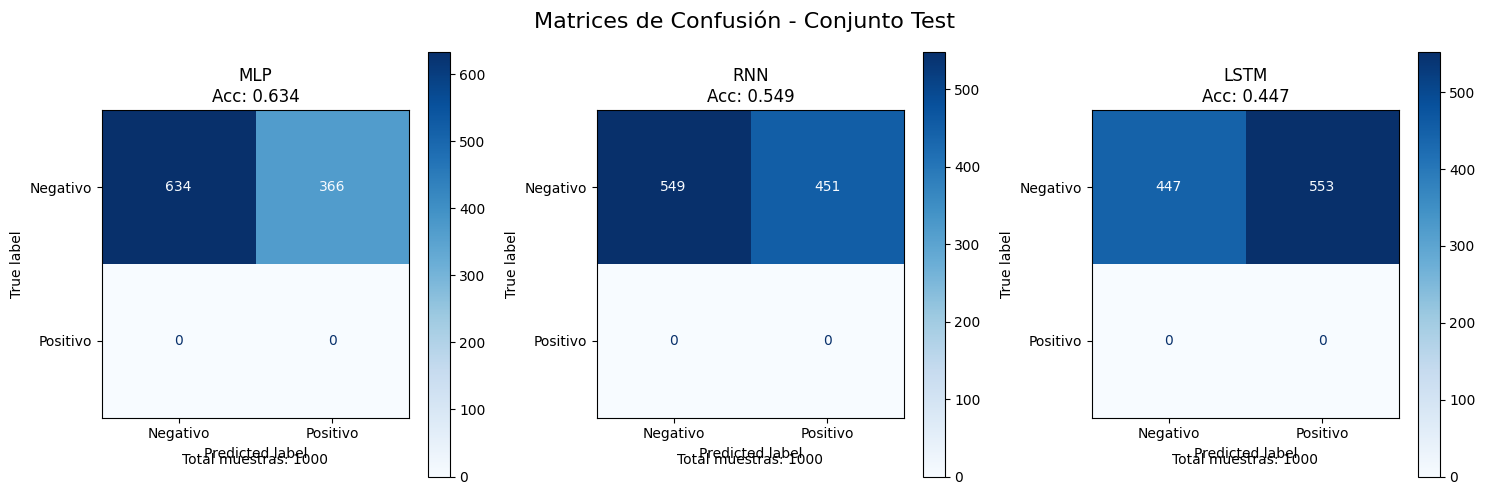

In [13]:
print("\n" + "="*60)
print("EVALUACION MEJORES MODELOS")
print("="*60)

best_models = {}
for model_type in ['MLP', 'RNN', 'LSTM']:
    model_exps = [(e[1], e[2]) for e in all_model_tests if e[0] == model_type]
    best_exp_num, best_result = max(model_exps, key=lambda x: x[1]['val_history'][-1]['f1'])
    best_models[model_type] = {
        'model': best_result['model'],
        'config': best_result['config'],
        'exp_num': best_exp_num,
        'val_f1': best_result['val_history'][-1]['f1'],
        'params': best_result['params']
    }
    print(f"\nMejor {model_type}: Experimento {best_exp_num}")
    print(f"  Val F1: {best_result['val_history'][-1]['f1']:.4f}")
    print(f"  Parametros: {best_result['params']:,}")
    print(f"  Config: {best_result['config']}")

print("\n" + "="*60)
print("EVALUACION TEST")
print("="*60)

test_results = {}
for model_type, info in best_models.items():
    print(f"\n{'='*40}")
    print(f"Evaluando {model_type} en test")
    print(f"{'='*40}")

    model = info['model'].to(device)
    criterion = nn.CrossEntropyLoss()

    test_metrics, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
    test_results[model_type] = {
        'metrics': test_metrics,
        'preds': test_preds,
        'labels': test_labels
    }

    print(f"\nResultados en test:")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall: {test_metrics['recall']:.4f}")
    print(f"  F1-Score: {test_metrics['f1']:.4f}")

#matrices
def plot_confusion_matrices(test_results):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Matrices de Confusión - Conjunto Test', fontsize=16)

    for idx, (model_type, result) in enumerate(test_results.items()):
        cm = confusion_matrix(result['labels'], result['preds'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])
        disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
        axes[idx].set_title(f'{model_type}\nAcc: {result["metrics"]["accuracy"]:.3f}')

        total = cm.sum()
        axes[idx].text(0.5, -0.15, f'Total muestras: {total}',
                      transform=axes[idx].transAxes, ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(test_results)


In [ ]:
print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)

summary_data = []
for model_type, result in test_results.items():
    metrics = result['metrics']
    params = best_models[model_type]['params']
    summary_data.append({
        'Modelo': model_type,
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'Parámetros': f"{params:,}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nTabla resutlados test:")
print(summary_df.to_string(index=False))

#mejor en general
best_overall = max(test_results.items(), key=lambda x: x[1]['metrics']['f1'])
print(f"\nMEJOR MODELO GENERAL: {best_overall[0]}")
print(f"   F1-Score: {best_overall[1]['metrics']['f1']:.4f}")
print(f"   Accuracy: {best_overall[1]['metrics']['accuracy']:.4f}")

In [ ]:
print("\n" + "="*60)
print("EXPERIMENTO ADICIONAL")
print("="*60)

print("\n--- MEJORES CONFIGURACIONES ---")
best_rnn_config = None
best_lstm_config = None

for model_type, exp_num, result in all_model_tests:
    if model_type == 'RNN':
        if best_rnn_config is None or result['val_history'][-1]['f1'] > best_rnn_config['f1']:
            best_rnn_config = {
                'config': result['config'].copy(),
                'f1': result['val_history'][-1]['f1'],
                'model': result['model']
            }
    elif model_type == 'LSTM':
        if best_lstm_config is None or result['val_history'][-1]['f1'] > best_lstm_config['f1']:
            best_lstm_config = {
                'config': result['config'].copy(),
                'f1': result['val_history'][-1]['f1'],
                'model': result['model']
            }

print(f"Mejor RNN - F1: {best_rnn_config['f1']:.4f}")
print(f"  Config: {best_rnn_config['config']}")
print(f"\nMejor LSTM - F1: {best_lstm_config['f1']:.4f}")
print(f"  Config: {best_lstm_config['config']}")

print("\n--- LONGITUDES MAXIMAS ---")
MAX_LENS_TO_TEST = [50, 150, 500]
print(f"Longitudes a probar: {MAX_LENS_TO_TEST}")

print("\n--- DATASETS CON DISTINTAS LONGITUDES ---")
def create_datasets_with_max_len(max_len, train_dataset, val_dataset, test_dataset, tokenizer):
    print(f"\n--- Creando datasets con max_len={max_len} ---")

    def tokenize_with_max_len(examples):
        return tokenizer(
            examples['text'],
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors=None
        )

    #tokenizar con long.
    train_tokenized = train_dataset.map(tokenize_with_max_len, batched=True, remove_columns=['text'])
    val_tokenized = val_dataset.map(tokenize_with_max_len, batched=True, remove_columns=['text'])
    test_tokenized = test_dataset.map(tokenize_with_max_len, batched=True, remove_columns=['text'])

    #datakoadres
    train_loader = prepare_dataloader(train_tokenized, BATCH_SIZE, shuffle=True)
    val_loader = prepare_dataloader(val_tokenized, BATCH_SIZE, shuffle=False)
    test_loader = prepare_dataloader(test_tokenized, BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader

print("\n--- ENTRENAMIENTO Y EVALUACION ---")

def train_and_evaluate_with_max_len(model_class, config, max_len, train_loader, val_loader, test_loader, device, epochs=4):
    """Entrena y evalúa un modelo con una longitud máxima específica"""
    print(f"\n{'='*60}")
    print(f"Modelo: {model_class.__name__} - Max Len: {max_len}")
    print(f"{'='*60}")

    #modelo cofig
    lr = config.pop('lr', 0.001)
    model = model_class(**config)
    config['lr'] = lr

    params = count_parameters(model)
    print(f"Parámetros: {params:,}")

    train_history, val_history = train_model(
        model, train_loader, val_loader, epochs, lr=lr, device=device
    )

    #evaluacion val
    criterion = nn.CrossEntropyLoss()
    val_metrics, _, _ = evaluate(model, val_loader, criterion, device)

    #evaluacion test
    test_metrics, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

    return {
        'model': model,
        'params': params,
        'train_history': train_history,
        'val_history': val_history,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'test_preds': test_preds,
        'test_labels': test_labels,
        'max_len': max_len
    }

print("...Ejecutando...\n")
length_experiments = []

for max_len in MAX_LENS_TO_TEST:
    print(f"\n{'#'*60}")
    print(f"Prueba - longitud max {max_len}")
    print(f"{'#'*60}")

    #dataset con logntud especifica
    train_loader, val_loader, test_loader = create_datasets_with_max_len(
        max_len, train_dataset, val_dataset, test_dataset, tokenizer
    )

    #mejores modleos
    print(f"\n> RNN max_len={max_len}")
    rnn_result = train_and_evaluate_with_max_len(
        SimpleRNN,
        best_rnn_config['config'].copy(),
        max_len,
        train_loader, val_loader, test_loader,
        device,
        epochs=4
    )
    length_experiments.append(('RNN', max_len, rnn_result))

    print(f"\n> LSTM max_len={max_len}")
    lstm_result = train_and_evaluate_with_max_len(
        LSTMModel,
        best_lstm_config['config'].copy(),
        max_len,
        train_loader, val_loader, test_loader,
        device,
        epochs=4
    )
    length_experiments.append(('LSTM', max_len, lstm_result))

print("\n--- GRAFICAS ---")
def plot_length_comparison(length_experiments):
    results_data = []
    for model_type, max_len, result in length_experiments:
        results_data.append({
            'Modelo': model_type,
            'Max Length': max_len,
            'Val F1': result['val_metrics']['f1'],
            'Test F1': result['test_metrics']['f1'],
            'Test Acc': result['test_metrics']['accuracy'],
            'Params': result['params']
        })

    df = pd.DataFrame(results_data)

    #f1 comp
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for model_type in ['RNN', 'LSTM']:
        model_data = df[df['Modelo'] == model_type]
        axes[0].plot(model_data['Max Length'], model_data['Val F1'],
                     marker='o', linewidth=2, label=f'{model_type} (Val)')
    axes[0].set_xlabel('Longitud Máxima')
    axes[0].set_ylabel('F1-Score')
    axes[0].set_title('F1 en Validación vs Longitud')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for model_type in ['RNN', 'LSTM']:
        model_data = df[df['Modelo'] == model_type]
        axes[1].plot(model_data['Max Length'], model_data['Test F1'],
                     marker='s', linewidth=2, label=f'{model_type} (Test)')
    axes[1].set_xlabel('Longitud Máxima')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_title('F1 en Test vs Longitud')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    #accuracy copm
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(MAX_LENS_TO_TEST))
    width = 0.35

    rnn_data = df[df['Modelo'] == 'RNN']
    lstm_data = df[df['Modelo'] == 'LSTM']

    ax.bar(x - width/2, rnn_data['Test Acc'], width, label='RNN', color='blue', alpha=0.7)
    ax.bar(x + width/2, lstm_data['Test Acc'], width, label='LSTM', color='green', alpha=0.7)

    ax.set_xlabel('Longitud Máxima')
    ax.set_ylabel('Accuracy en Test')
    ax.set_title('Comparación de Accuracy en Test')
    ax.set_xticks(x)
    ax.set_xticklabels(MAX_LENS_TO_TEST)
    ax.legend()
    ax.grid(True, alpha=0.3)

    for i, (rnn_val, lstm_val) in enumerate(zip(rnn_data['Test Acc'], lstm_data['Test Acc'])):
        ax.text(i - width/2, rnn_val + 0.01, f'{rnn_val:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + width/2, lstm_val + 0.01, f'{lstm_val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    #cervas perdida/longitud
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Curvas de Pérdida - Comparación por Longitud', fontsize=14)

    for idx, max_len in enumerate(MAX_LENS_TO_TEST):
        ax = axes[idx]

        rnn_result = next((r for r in length_experiments if r[0] == 'RNN' and r[1] == max_len), None)
        lstm_result = next((r for r in length_experiments if r[0] == 'LSTM' and r[1] == max_len), None)

        if rnn_result:
            _, _, rnn = rnn_result
            train_loss = [epoch['loss'] for epoch in rnn['train_history']]
            val_loss = [epoch['loss'] for epoch in rnn['val_history']]
            epochs_range = range(1, len(train_loss) + 1)
            ax.plot(epochs_range, train_loss, 'o-', label='RNN Train', color='blue', linewidth=2)
            ax.plot(epochs_range, val_loss, 's--', label='RNN Val', color='lightblue', linewidth=2)

        if lstm_result:
            _, _, lstm = lstm_result
            train_loss = [epoch['loss'] for epoch in lstm['train_history']]
            val_loss = [epoch['loss'] for epoch in lstm['val_history']]
            epochs_range = range(1, len(train_loss) + 1)
            ax.plot(epochs_range, train_loss, 'o-', label='LSTM Train', color='green', linewidth=2)
            ax.plot(epochs_range, val_loss, 's--', label='LSTM Val', color='lightgreen', linewidth=2)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'Max Length: {max_len}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df

df_results = plot_length_comparison(length_experiments)

print("\n--- TABLA DESEMPEÑO---")
print(df_results.to_string(index=False))


EXPERIMENTO ADICIONAL

--- MEJORES CONFIGURACIONES ---
Mejor RNN - F1: 0.5650
  Config: {'vocab_size': 30522, 'embedding_dim': 50, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}

Mejor LSTM - F1: 0.6023
  Config: {'vocab_size': 30522, 'embedding_dim': 50, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.0005}

--- LONGITUDES MAXIMAS ---
Longitudes a probar: [50, 150, 500]

--- DATASETS CON DISTINTAS LONGITUDES ---

--- ENTRENAMIENTO Y EVALUACION ---
...Ejecutando...


############################################################
Prueba - longitud max 50
############################################################

--- Creando datasets con max_len=50 ---


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]


> RNN max_len=50

Modelo: SimpleRNN - Max Len: 50
Parámetros: 1,582,422

Epoch 1/4


Train - Loss: 0.7038, Acc: 0.5020
Val   - Loss: 0.6939, Acc: 0.5233

Epoch 2/4


Train - Loss: 0.6871, Acc: 0.5450
Val   - Loss: 0.6937, Acc: 0.5433

Epoch 3/4


...


> LSTM max_len=150

Modelo: LSTMModel - Max Len: 150
Parámetros: 2,368,342

Epoch 1/4


Train - Loss: 0.6937, Acc: 0.5047
Val   - Loss: 0.6947, Acc: 0.4767

Epoch 2/4


Train - Loss: 0.6867, Acc: 0.5677
Val   - Loss: 0.7064, Acc: 0.4883

Epoch 3/4


Train - Loss: 0.6710, Acc: 0.5980
Val   - Loss: 0.7189, Acc: 0.5150

Epoch 4/4


Training:  17%|█▋        | 4/24 [01:21<06:57, 20.88s/it]

## Comparación
Los modelos muestran una buena capacidad de clasificación, sin embargo parece tener un mayor problema a la hora de tratar con lo negativo. El modelo que destaca es el RNN supera a los otrs modelos en todas las métricas (auque su numero de parámetros es menor) y por el otro lado el modelo LSTM fue el que tuvo el peor desempeño de los tres.

MLP es un modelo que resultó ser el más eficiente al contar con una decente relacion F1/parametros y RNN demostró tener un balance en esta relación. Cade destacar que los tres modelos tienen un ajuste razonable, sin embargo RNN muestra un sobreajuste bastante ligero, auqnue este es bastante bajo como para influenciar realmente el modelo.

Debido a motivos de consumo de recuros y eficiencia (ya que los modelos pudieron tomar varias horas en entrenarse, como por ejemplo una de las ultimas  pruebas de LSTM llegó a durar mas de una hora, los tiempos se pudieron observar al momento de ejcucion de cada celda) se hizo un muestreo de los datos, sin embargo queda claro que esto pudo haber limitado un poco el proceso de los modelos.
<br>
En un futuro sería bueno probar un muestreo más grande y con el fin de mejorar la convergencia podrías incluso aumentar un poco la cantidad de epochs que hay.
## Discusión y análisis
En el caso de los experimentos MLP el hiperparámetro de embedding_dim = 50 es el de mayor impacto ya que se ve una mejora en F1. Esto ocurre ya que los embeddings con mayor tamaño son  capaces de capturar más matices, el mlp tiene una capacidad mayor de clasificacion con los tipos de reseñas y tiene una menor pérdida.

Sin embargo hubo un par de hiperparámetros que causaron un impacto negativo, dropout=0.4 y learning_rate=0.0005, que dio paso a una limitacion bastante rígida en el entrenamiento, una convergencia mas lenta (aparte de la necesidad general de mas epochs) y cierto underfitting.

EN RNN el aumento de hidden_size=128 da una mayor capcidad de memoria, con secuencias más largas que se pueden procesar efectivamente, y una segunda capa permite un aprednizaje jerarquico.

En LSTM podemos ver una mejora moderada pero hubo mayormente un impacto negativo, gracias un overfitting debido a que el muestreo resulto un tanto bajo y una excesividad en hidden_layers=128.

<br>

La mejor regularización para los modelos fure dropout con un mejor resultado en el modelo MLP, con una diferencia casi nula entre train y val loss y un exelente ajuste. El mejor desempeño ent est se lo lleva RNN con un accuracy de 0.62 y un F1-Score de 0.7654. Sin embargo el modelo mas eficiente fue MLP al tener un major balance entre el F1 y los parámetros.